dados ['olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object

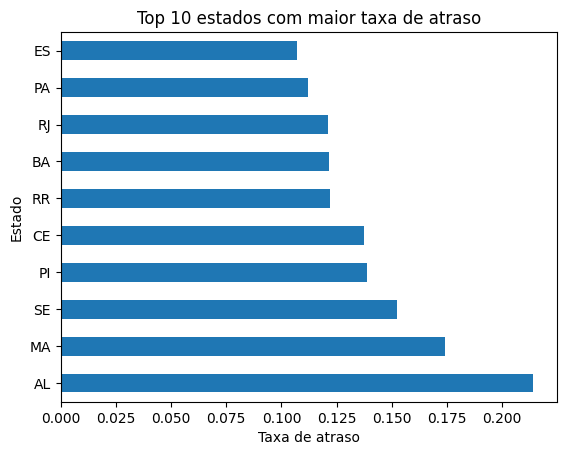

,review_score
is_delayed,
False,4.289842
True,2.271139


In [40]:
# Explorando a estrutura das pastas e arquivos
for root, dirs, files in os.walk('dados'):
    print(root, files)

# Leitura dos dados principais
orders = pd.read_csv('dados/olist_orders_dataset.csv')
order_items = pd.read_csv('dados/olist_order_items_dataset.csv')
customers = pd.read_csv('dados/olist_customers_dataset.csv')

# Visualização inicial dos dados
orders.head()
orders.info()

# Convertendo colunas de data para o formato datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Conferindo se a conversão foi realizada corretamente
orders.info()

# ==============================
# Criação de métricas logísticas
# ==============================

# Calculando tempo de entrega em dias
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Calculando atraso (diferença entre entrega real e estimada)
orders['delay'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

# Identificando pedidos com atraso
orders['is_delayed'] = orders['delay'] > 0

# Visualizando as novas colunas criadas
orders[['delivery_time', 'delay', 'is_delayed']].head()

# Removendo pedidos que não possuem data de entrega
orders = orders.dropna(subset=['order_delivered_customer_date'])

# Juntando os dados de pedidos com os dados dos clientes
df = orders.merge(customers, on='customer_id', how='left')

# ==============================
# Análises
# ==============================

# Calculando tempo médio de entrega
df['delivery_time'].mean()

# Calculando atraso médio
df['delay'].mean()

# Calculando taxa de atraso
delay_rate = df['is_delayed'].mean()
print(f"Taxa de atraso: {delay_rate*100:.2f}%")

# Exibindo principais métricas
print(f"Tempo médio de entrega: {df['delivery_time'].mean():.2f} dias")
print(f"Atraso médio: {df['delay'].mean():.2f} dias")

# Calculando taxa de atraso por estado
df.groupby('customer_state')['is_delayed'].mean().sort_values(ascending=False).head(10)

# Salvando resultado para reutilização
delay_by_state = df.groupby('customer_state')['is_delayed'].mean().sort_values(ascending=False)
delay_by_state.head(10)

# ==============================
# Visualização
# ==============================

import matplotlib.pyplot as plt

# Gráfico dos estados com maior taxa de atraso
delay_by_state.head(10).plot(kind='barh')
plt.title('Top 10 estados com maior taxa de atraso')
plt.xlabel('Taxa de atraso')
plt.ylabel('Estado')
plt.show()

# ==============================
# Impacto na satisfação
# ==============================

# Leitura dos dados de avaliações
reviews = pd.read_csv('dados/olist_order_reviews_dataset.csv')

# Juntando avaliações com os pedidos
df = df.merge(reviews, on='order_id', how='left')

# Comparando satisfação entre pedidos com e sem atraso
df.groupby('is_delayed')['review_score'].mean()

# ==============================
# Conclusão
# ==============================

## 📌 Conclusão

#A maioria dos pedidos foi entregue dentro do prazo.

#A taxa de atraso é baixa, mas alguns estados apresentam mais atrasos que outros.

#Também foi possível observar que pedidos atrasados possuem menor avaliação dos clientes.